# Loan Approval Prediction

Notebook feito com intuito de predizer se um empréstimo será aprovado, utilizando KNN, Árvore de Decisão, Naive Bayes e SVM. Foram utilizados pipelines, cross-validation e otimização de hiperparâmetros.

## 1. Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

## 2. Carregamento dos Dados

In [26]:
url = "https://raw.githubusercontent.com/pabloghid/loan_approval_prediction/refs/heads/main/notebook/loan_approval.csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
df.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Análise Exploratória

In [27]:
print("Tipos de dados:")
print(df.dtypes)
print("\nValores nulos por coluna:")
print(df.isnull().sum())
print("\nDistribuição do target:")
print(df['Loan_Status'].value_counts())

Tipos de dados:
Loan_ID                  str
Gender                   str
Married                  str
Dependents               str
Education                str
Self_Employed            str
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area            str
Loan_Status              str
dtype: object

Valores nulos por coluna:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

Distribuição do target:
Loan_Status
Y    422
N    192
Name: count, dtype: int64


## 4. Limpeza e Pré-processamento

### 4.1 Tratamento de valores nulos

Em vez de excluir linhas com nulos (o que reduziria o dataset), mudamos os dados que são categorias, utilizado moda (valores mais frequentes) e numéricos, utilizando mediana.

In [28]:
# Variáveis categóricas
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term']:
    df[col] = df[col].fillna(df[col].mode()[0])

# Credit_History (float): substitui pela moda
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

# LoanAmount (numérica): substitui pela mediana
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

print("Nulos restantes:", df.isnull().sum().sum())

Nulos restantes: 0


### 4.2 Conversão para numérico

Para poder utilizar predição, precisamos transformar todos os dados em numéricos:
- Dependents: '3+' vira 3 (int)
- Gender, Married, e outras variáveis binárias, utilizamos LabelEncoder, virando 0 ou 1
- Property_Area (3 categorias sem ordem) utilizamos "get_dummies" (one-hot encoding) para adicionar valores quantitativos aos valores qualitativos.

In [29]:
# Remove ID (não é utilizado na predição)
df = df.drop('Loan_ID', axis=1)

# Dependents
df['Dependents'] = df['Dependents'].replace('3+', '3').astype(int)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].astype(float)

# LabelEncoder para variáveis binárias
le = LabelEncoder()
for col in ['Gender', 'Married', 'Education', 'Self_Employed', 'Loan_Status']:
    df[col] = le.fit_transform(df[col].astype(str))

# One-hot para Property_Area (sem hierarquia entre Urban/Rural/Semiurban)
df = pd.get_dummies(df, columns=['Property_Area'], drop_first=False)

print("Colunas finais:", df.columns.tolist())
df.head()

Colunas finais: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Loan_Status', 'Property_Area_Rural', 'Property_Area_Semiurban', 'Property_Area_Urban']


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,1,False,False,True
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,True,False,False
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,1,False,False,True
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,1,False,False,True
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,1,False,False,True


## 5. Holdout — Separação Treino/Teste

Separamos 80% para treino e 20% para teste. `stratify=y` preserva a proporção das classes em ambos os conjuntos.

In [30]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")

Treino: 491 amostras | Teste: 123 amostras


## 6. Modelagem com Pipelines

Cada pipeline encadeia:
1. **StandardScaler** — padroniza (média 0, desvio 1); obrigatório para KNN e SVM
2. O classificador

Avaliamos com **StratifiedKFold (5 folds)** para garantir representação balanceada das classes.

In [31]:
pipelines = [
    ('KNN',        Pipeline([('scaler', StandardScaler()), ('clf', KNeighborsClassifier())])),
    ('DecTree',    Pipeline([('scaler', StandardScaler()), ('clf', DecisionTreeClassifier(random_state=42))])),
    ('NaiveBayes', Pipeline([('scaler', StandardScaler()), ('clf', GaussianNB())])),
    ('SVM',        Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))])),
]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

for name, pipe in pipelines:
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    print(f"{name:12s} → CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

KNN          → CV Accuracy: 0.7616 ± 0.0560


DecTree      → CV Accuracy: 0.7067 ± 0.0307
NaiveBayes   → CV Accuracy: 0.7800 ± 0.0419
SVM          → CV Accuracy: 0.7942 ± 0.0438


### Comparação Visual (Cross-Validation)

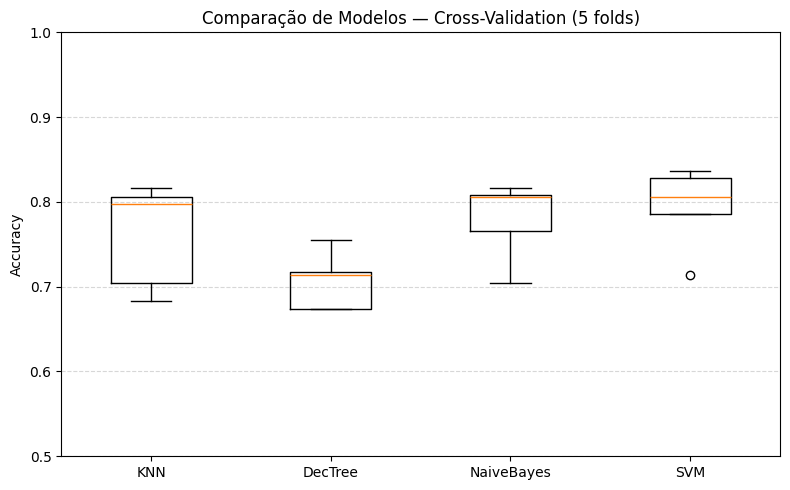

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(cv_results.values(), labels=cv_results.keys())
ax.set_title('Comparação de Modelos — Cross-Validation (5 folds)')
ax.set_ylabel('Accuracy')
ax.set_ylim(0.5, 1.0)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Otimização de Hiperparâmetros (GridSearchCV)

Testamos combinações dos principais hiperparâmetros de cada algoritmo usando o mesmo `cv` de 5 folds.

In [33]:
param_grids = {
    'KNN': {
        'clf__n_neighbors': [3, 5, 7, 11],
        'clf__weights':     ['uniform', 'distance'],
    },
    'DecTree': {
        'clf__max_depth':        [3, 5, 7, None],
        'clf__min_samples_leaf': [1, 5, 10],
    },
    'NaiveBayes': {
        'clf__var_smoothing': [1e-9, 1e-7, 1e-5],
    },
    'SVM': {
        'clf__C':      [0.1, 1, 10],
        'clf__kernel': ['linear', 'rbf'],
    },
}

best_models = {}

for name, pipe in pipelines:
    grid = GridSearchCV(pipe, param_grids[name], cv=cv, scoring='accuracy', n_jobs=-1)
    grid.fit(X_train, y_train)
    best_models[name] = grid.best_estimator_
    print(f"{name:12s} → Best CV: {grid.best_score_:.4f} | {grid.best_params_}")

KNN          → Best CV: 0.7820 | {'clf__n_neighbors': 11, 'clf__weights': 'uniform'}
DecTree      → Best CV: 0.7962 | {'clf__max_depth': 3, 'clf__min_samples_leaf': 10}
NaiveBayes   → Best CV: 0.7800 | {'clf__var_smoothing': 1e-09}
SVM          → Best CV: 0.7983 | {'clf__C': 0.1, 'clf__kernel': 'linear'}


## 8. Avaliação Final no Conjunto de Teste (Holdout)

In [34]:
print(f"{'Modelo':<12} {'Accuracy':>10}")
print("-" * 24)

test_scores = {}
for name, model in best_models.items():
    acc = accuracy_score(y_test, model.predict(X_test))
    test_scores[name] = acc
    print(f"{name:<12} {acc:>10.4f}")

Modelo         Accuracy
------------------------
KNN              0.8293
DecTree          0.8537
NaiveBayes       0.8455
SVM              0.8537


In [35]:
# Relatório detalhado do melhor modelo
best_name = max(test_scores, key=test_scores.get)
best_model = best_models[best_name]

print(f"Melhor modelo: {best_name} (Accuracy = {test_scores[best_name]:.4f})\n")
print(classification_report(
    y_test, best_model.predict(X_test),
    target_names=['Reprovado', 'Aprovado']
))

Melhor modelo: DecTree (Accuracy = 0.8537)

              precision    recall  f1-score   support

   Reprovado       0.95      0.55      0.70        38
    Aprovado       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



## 9. Exportação do Melhor Modelo

In [36]:
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)


## 10. Predição no test.csv

O test.csv não possui Loan_Status. Aplicamos as mesmas transformações do treino e geramos as predições.

In [42]:
df_test = pd.read_csv('test.csv')
loan_ids = df_test['Loan_ID'].copy()
app_income = df_test['ApplicantIncome'].copy()
loan_amount = df_test['LoanAmount'].copy()
cred_history = df_test['Credit_History'].copy()
prop_area = df_test['Property_Area'].copy()

# Input
for col in ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Loan_Amount_Term']:
    df_test[col] = df_test[col].fillna(df_test[col].mode()[0])
df_test['Credit_History'] = df_test['Credit_History'].fillna(df_test['Credit_History'].mode()[0])
df_test['LoanAmount'] = df_test['LoanAmount'].fillna(df_test['LoanAmount'].median())

# Remover ID e converter tipos
df_test = df_test.drop('Loan_ID', axis=1)
df_test['Dependents'] = df_test['Dependents'].replace('3+', '3').astype(int)
df_test['Loan_Amount_Term'] = df_test['Loan_Amount_Term'].astype(float)

# LabelEncoder
for col in ['Gender', 'Married', 'Education', 'Self_Employed']:
    df_test[col] = le.fit_transform(df_test[col].astype(str))

# One-hot Property_Area
df_test = pd.get_dummies(df_test, columns=['Property_Area'], drop_first=False)

# Garante mesmas colunas do treino (caso alguma categoria não apareça no test)
for col in X.columns:
    if col not in df_test.columns:
        df_test[col] = 0
df_test = df_test[X.columns]

# Predição
predictions = best_model.predict(df_test)
pred_labels = ['Y' if p == 1 else 'N' for p in predictions]

result = pd.DataFrame({'Loan_ID': loan_ids, 'ApplicantIncome': app_income, 'LoanAmount': loan_amount, 'Credit_History': cred_history, 'PropArea': prop_area, 'Loan_Status': pred_labels})
result.to_csv('predictions.csv', index=False)

print(f"Predições geradas: {len(result)} amostras")
print(result['Loan_Status'].value_counts())
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df_test_viz = df_test.copy()
df_test_viz.insert(0, 'Loan_ID', loan_ids.values)
df_test_viz.insert(1, 'Loan_Status', pred_labels)

df_test_viz.to_csv('predictions.csv', index=False)

print(f"Predições geradas: {len(df_test_viz)} amostras")
print(df_test_viz['Loan_Status'].value_counts())
df_test_viz.head(50)

Predições geradas: 367 amostras
Loan_Status
Y    308
N     59
Name: count, dtype: int64
Predições geradas: 367 amostras
Loan_Status
Y    308
N     59
Name: count, dtype: int64


,Loan_ID,Loan_Status,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Rural,Property_Area_Semiurban,Property_Area_Urban
0,LP001015,Y,1,1,0,0,0,5720,0,110.0,360.0,1.0,False,False,True
1,LP001022,Y,1,1,1,0,0,3076,1500,126.0,360.0,1.0,False,False,True
2,LP001031,Y,1,1,2,0,0,5000,1800,208.0,360.0,1.0,False,False,True
3,LP001035,Y,1,1,2,0,0,2340,2546,100.0,360.0,1.0,False,False,True
4,LP001051,Y,1,0,0,1,0,3276,0,78.0,360.0,1.0,False,False,True
5,LP001054,Y,1,1,0,1,1,2165,3422,152.0,360.0,1.0,False,False,True
6,LP001055,Y,0,0,1,1,0,2226,0,59.0,360.0,1.0,False,True,False
7,LP001056,N,1,1,2,1,0,3881,0,147.0,360.0,0.0,True,False,False
8,LP001059,Y,1,1,2,0,0,13633,0,280.0,240.0,1.0,False,False,True
9,LP001067,Y,1,0,0,1,0,2400,2400,123.0,360.0,1.0,False,True,False
